In [1]:
import pandas as pd
import cnsplots as cns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.image as mpimg
import cairosvg
import tempfile
import numpy as np
import seaborn as sns
from pathlib import Path
from matplotlib.colors import to_rgb, to_hex
from collections import defaultdict
import os
from openTSNE import TSNE
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support
from dna_features_viewer import GraphicFeature, GraphicRecord
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import tol_colors as tc

In [2]:
# define constants
COLNAME = "assigned_subcat" # hierarchy level to be analyzed, from here on defined as 'subcategory'
COLNAME_MAP = "Subcategory" # respective column name in the mapping file
TOP_COLNAME = "assigned_top" # hierarchy level to serve as top-level category/mapping
TOP_COLNAME_MAP = "Top_Category" # respective column name in the mapping file
SEQ_ID = 0.95 # sequence identity threshold used for clustering (part of input data file name)
COLORBLIND = True

# assertions
assert COLNAME and TOP_COLNAME in ["assigned_subcat", "assigned_cat", "assigned_top"], "Invalid column name. Must be one of 'assigned_subcat', 'assigned_cat', or 'assigned_top'."
assert COLNAME_MAP and TOP_COLNAME_MAP in ["Subcategory", "Category", "Top_Category"], "Invalid column name. Must be one of 'Subcategory', 'Category', or 'Top_Category'."
assert SEQ_ID in [0.95, 0.2], "Invalid sequence identity threshold. Must be one of 0.95, 0.2."

In [3]:
#######################
# plotting utilities 
#######################

# define colors for top-level categories
if COLORBLIND:
    topcat_colors = {
        "Assembly": '#6DA1D6',
        "Structural": '#3E79BD',
        "Host takeover": '#F4A937',
        "NA processing": '#C1A7C4',
        "Replication": '#AD7BA4',
        "Translation": '#93C7EC',
        "AMGs": '#B8D29E', #"#ffa200",
        "Lysis": '#2C925B', 
        "Anti-Defense": '#D9070D', 
        "Effectors": '#EB7121',
        "Lysogeny": '#7BB47D', #"#ff007b",
        "Unknown": '#FFFFFF'
    }
else:
    topcat_colors = {
        "Assembly": "#007BFF",
        "Structural": "#1e00ff",
        "Host takeover": "#2fff00",
        "NA processing": "#00ffb7",
        "Replication":"#00d9ff",
        "Translation": "#f6ff00",
        "AMGs": "#ffbf00", #"#ffa200",
        "Lysis": "#ff0000", 
        "Anti-Defense": "#ff00dd", 
        "Effectors": "#8e01f9", 
        "Lysogeny": "#FF5A00", #"#ff007b",
        "Unknown": "#bdbdbd"
    }

# define colors for mid-level categories
cat_colors = {
    "Transcriptional regulation": "#2fff00",
    "Transcriptional inhibition": "#02d136",
    "Host resource takeover": "#39fa69",
    "Transcriptional antitermination": "#60c006",
    "Host takeover via phosphorylation": "#3ea52e", 
    "Lytic switch": "#74d216",
    "Transcription factor": "#3C6D0F",
    "Transcriptional machinery": "#0D6806",

    "Integration": "#00ffb7",
    "Excision and transcriptional regulation": "#0dd09c",
    "DNA repair": "#0D916D",
    "Recombination": "#036D51",
    "RNA modification": "#71F8D4",
    "RNA cleavage": "#37F9AF",
    "RNA sealing": "#14AC72",

    "Maintenance": "#FF5A00", #"#ff007b",

    "Protein synthesis": "#f4fa51",
    "Ribosomal protein": "#f3fb00",
    "Translation regulation": "#d0d703",
    "Ribosome biogenesis": "#a0a512",
    "Protein maturation and folding": "#FFFF00",

    "Head morphogenesis": "#4099F9",
    "Head-to-tail joining": "#74B7FE",
    "Tail assembly": "#0F559F",
    "Baseplate assembly": "#014894",
    "DNA packaging": "#0E437B",

    "Replication initiation":"#00d9ff",
    "DNA replication":"#3AAEC3",

    "Capsid": "#1e00ff",
    "DNA injection": "#1903c1",
    "Tail and Fibers": "#553ffb",
    "Baseplate": "#3c2dad",

    "Host polysaccharide degradation": "#e24141", 
    "Endolysin": "#ff0000", 
    "Spanin": "#a90202", 
    "Lysis regulation": "#7D1C1C", 

    "Anti-Restriction": "#ff00dd", 
    "Anti-TA": "#e634f6", 
    "Anti-Defense": "#df00fd",

    "Nucleotide metabolism": "#ffbf00",
    "Other AMGs": "#ff9100",

    "Virulence factors": "#af01f9", 
    "Stress response and damage protection": "#7d01f9", 
    "Membrane transport and signaling": "#a312c3", 
    "Superinfection exclusion": "#710589", 

    "Unknown": "#bdbdbd", 
}


def adjust_color(color, factor=0.2, lighten=True):
    """Mix a color with white or black. The closer the value to 1, the more white/black contained"""
    r, g, b = to_rgb(color)

    if lighten:
        r = r + (1-r)*factor
        g = g + (1-g)*factor
        b = b + (1-b)*factor
    else:
        r = r * (1-factor)
        g = g * (1-factor)
        b = b * (1-factor)

    return to_hex((r, g, b))


def get_factor_range(n, min_n=2, max_n=20, min_spread=0.1, max_spread=0.5):
    """Returns factor range depending on n"""
    # normalize n to 0-1
    t = min(1, max(0, (n - min_n) / (max_n - min_n)))

    spread = min_spread + t * (max_spread - min_spread)

    base = 0.15 
    return base, base+spread


def generate_subcategory_colors(topcat_colors, cat_to_top):
    """Generate colors for subcategories based on their top-level category colors."""
    top_to_sub = defaultdict(list)
    for sub, top in cat_to_top.items():
        top_to_sub[top].append(sub)

    sub_colors = {}

    for top, subs in top_to_sub.items():
        base_color = topcat_colors.get(top, "#999999")
        n = len(subs)

        low, high = get_factor_range(n)

        if n == 1:
            factors = [0.2]
        else:
            factors = np.linspace(low, high, n)

        for i, (sub, factor) in enumerate(zip(subs, factors)):
            lighten = (i % 2 == 0) # alternate
            sub_colors[sub] = adjust_color(base_color, factor, lighten)

    return sub_colors

# lighten top-level category colors
if COLORBLIND:
    topcat_colors_adjusted = topcat_colors
else:
    topcat_colors_adjusted = {
    k: adjust_color(v, factor=0.2, lighten=True)
    for k, v in topcat_colors.items()
}

In [4]:
# read mapping file for keywords to sub-, mid-, and top-level categories
keywords_map = pd.read_csv("./input_data/Category_map.csv") 

# create a mapping from subcategories to top-level categories
cat_to_top = keywords_map[[COLNAME_MAP, TOP_COLNAME_MAP]].drop_duplicates().set_index(COLNAME_MAP)[TOP_COLNAME_MAP].to_dict()

def clean_df(df, colname):
    """"Helper function to clean the dataframe by replacing entries with semicolons in the specified column with 'Unknown'."""
    mask = df[colname].str.contains(";")
    df.loc[mask, colname] = "Unknown"
    return df

In [5]:
#######################
# Panel A: Precision, Recall, F1 for MLP, CNN, CNN+MLP for subcategory prediction (using BacVir95 model)
#######################

mlp_metrics = pd.read_csv("./input_data/BacVir95_metrics_MLP.csv")
mlp_metrics["Model"] = "MLP"
cnn_metrics = pd.read_csv("./input_data/BacVir95_metrics.csv")
cnn_metrics["Model"] = "CNN"
cnnmlp_metrics = pd.read_csv("./input_data/BacVir95_metrics_CNNMLP.csv")
cnnmlp_metrics["Model"] = "CNN+MLP"

metrics = pd.concat([mlp_metrics, cnn_metrics, cnnmlp_metrics])
metrics.rename(columns={"bv_test_indiv_f1": "F1", "bv_test_indiv_recall": "Recall", "bv_test_indiv_precision": "Precision"}, inplace=True)
metrics_long = metrics.melt(id_vars="Model", value_vars=["F1", "Recall", "Precision"], var_name="Metric", value_name="Score")

In [6]:
#######################
# Panel B: Confusion matrix for test set proteins (BacVir95 model)
#######################
test_95 = pd.read_csv("./input_data/BacVir95_test.tsv", sep="\t")
# Get all subcategory labels
subcat_labels = sorted(set(test_95["target"]) | set(test_95["pred"]))

# Subcategory confusion matrix
cm_subcat = confusion_matrix(test_95["target"], test_95["pred"], labels=subcat_labels)

top_labels = ["Structural", "NA processing", "Assembly", "AMGs", "Host takeover", "Replication", "Lysis", "Effectors", "Anti-Defense", "Translation", "Lysogeny"]

cm_top = np.zeros((len(top_labels), len(top_labels)), dtype=int)

for i, true_subcat in enumerate(subcat_labels):
    true_top = cat_to_top[true_subcat]
    true_top_idx = top_labels.index(true_top)

    for j, pred_subcat in enumerate(subcat_labels):
        pred_top = cat_to_top[pred_subcat]
        pred_top_idx = top_labels.index(pred_top)

        cm_top[true_top_idx, pred_top_idx] += cm_subcat[i, j]

cm_norm = np.divide(cm_top, cm_top.sum(axis=1, keepdims=True),
    out=np.zeros_like(cm_top, dtype=float), where=cm_top.sum(axis=1, keepdims=True) != 0)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=top_labels)

In [7]:
#######################
# Panel C: Metrics BASEL BacVir95
#######################
basel_95 = pd.read_csv(f"./input_data/BASEL_BacVir95_final.tsv", sep="\t")
basel_95 = basel_95[basel_95["assigned_subcat_initial"] != "Unknown"]

# calculate metrics
precision, recall, f1, support = precision_recall_fscore_support(basel_95["assigned_subcat_initial"], basel_95["Predicted Class"], zero_division=0)
metrics_95 = {"Precision": precision, "Recall": recall, "F1": f1, "support": support}
metrics_95 = pd.DataFrame(metrics_95)
metrics_95_long = metrics_95.melt(
    value_vars=["F1", "Recall", "Precision"],
    var_name="Metric",
    value_name="Score"
)

In [8]:
#######################
# Panel D: Confusion matrix for test set proteins (BacVir20 model)
#######################
test_20 = pd.read_csv("./input_data/BacVir20_test.tsv", sep="\t")
# Get all subcategory labels
subcat_labels = sorted(set(test_20["target"]) | set(test_20["pred"]))

# Subcategory confusion matrix
cm_subcat20 = confusion_matrix(test_20["target"], test_20["pred"], labels=subcat_labels)

cm_top20 = np.zeros((len(top_labels), len(top_labels)), dtype=int)

for i, true_subcat in enumerate(subcat_labels):
    true_top = cat_to_top[true_subcat]
    true_top_idx = top_labels.index(true_top)

    for j, pred_subcat in enumerate(subcat_labels):
        pred_top = cat_to_top[pred_subcat]
        pred_top_idx = top_labels.index(pred_top)

        cm_top20[true_top_idx, pred_top_idx] += cm_subcat20[i, j]

cm_norm20 = np.divide(cm_top20, cm_top20.sum(axis=1, keepdims=True),
    out=np.zeros_like(cm_top20, dtype=float), where=cm_top20.sum(axis=1, keepdims=True) != 0)

disp20 = ConfusionMatrixDisplay(confusion_matrix=cm_norm20, display_labels=top_labels)

In [9]:
#######################
# Panel E: Metrics BASEL BacVir20
#######################
basel_20 = pd.read_csv(f"./input_data/BASEL_BacVir20_final.tsv", sep="\t")
basel_20_known = basel_20[basel_20["assigned_subcat_initial"] != "Unknown"]

# calculate metrics
precision, recall, f1, support = precision_recall_fscore_support(basel_20_known["assigned_subcat_initial"], basel_20_known["Predicted Class"], zero_division=0)
metrics_20 = {"Precision": precision, "Recall": recall, "F1": f1, "support": support}
metrics_20 = pd.DataFrame(metrics_20)
metrics_20_long = metrics_20.melt(
    value_vars=["F1", "Recall", "Precision"],
    var_name="Metric",
    value_name="Score"
)

In [10]:
colors = [to_hex(c) for c in tc.PRGn(np.linspace(0, 1, 20))]
print(colors)

['#762a83', '#844793', '#9363a4', '#a37eb4', '#b493c3', '#c6aad2', '#d5bddc', '#e5d2e7', '#ede0ed', '#f4f0f4', '#f1f6f0', '#e4f2e0', '#d7efd0', '#c3e2b9', '#b1d6a3', '#90c789', '#6fb771', '#4ea459', '#358e48', '#1b7837']


/tmp/ipykernel_1728197/1924513827.py:15: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=metrics_long, x="Metric", y="Score", hue="Model", dodge=True, color="black", alpha=0.3, size=1, ax=ax)
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont

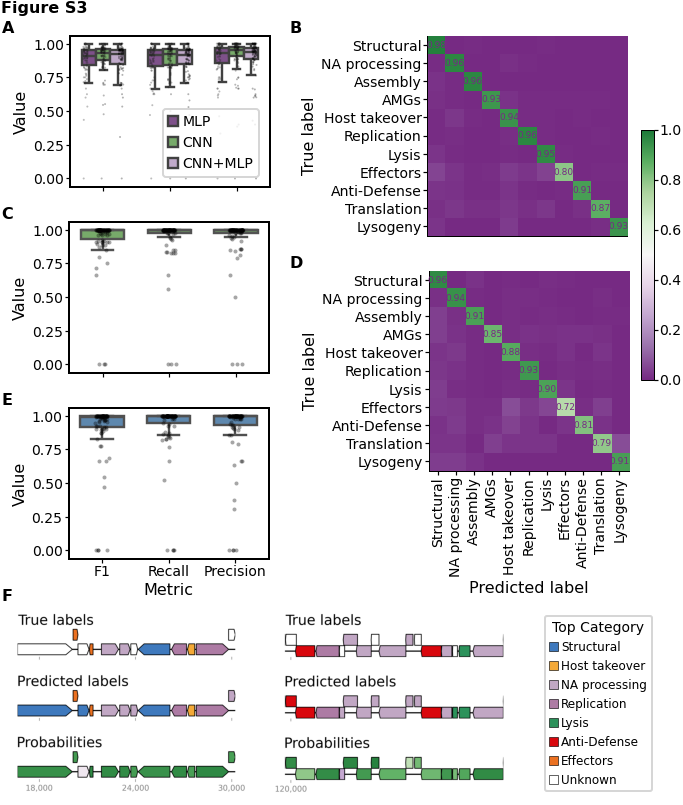

In [11]:
cns.settings.title_fontweight = "normal"
mp = cns.multipanel(
    max_width=400, title="Figure S3", title_fontweight="bold", loc="left"
)

######################
# Panel A: Precision, Recall, F1 of MLP, CNN, CNN+MLP for subcategory prediction
mp.panel("A", 100, 75.5)
ax = plt.gca()

palette_arch = {"MLP": '#844793', "CNN": cns.GREEN, "CNN+MLP": '#C2A5CF'}

sns.boxplot(data=metrics_long, x="Metric", y="Score", hue="Model", palette=palette_arch, width=0.65, linewidth=1.2, fliersize=0, ax=ax)

sns.stripplot(data=metrics_long, x="Metric", y="Score", hue="Model", dodge=True, color="black", alpha=0.3, size=1, ax=ax)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:3], labels[:3], title=None, frameon=True, loc="lower right", bbox_to_anchor=(0.98, 0.02))

ax.set_xlabel("")
ax.set_xticklabels([])
ax.set_ylabel("Value")
ax.set_ylim(-0.06, 1.06)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1) 

######################
# Panel B: Confusion matrix for test set proteins (BacVir95 model)
mp.panel("B", 100, 100)
ax = plt.gca()
form = ".2f"
text_fs = 4.5

# use confusion matrix display (disp) which has been instantiated earlier
disp.plot(ax=ax, cmap=tc.PRGn, values_format=form, im_kw={"vmin": 0, "vmax": 1}, xticks_rotation=90, text_kw={"fontsize": text_fs},
colorbar=False)

threshold = 0.1
for text, value in zip(disp.text_.ravel(), cm_norm.ravel()):
    if value < threshold:
        text.set_text("")
ax.set_xticks([])
ax.set_xlabel("")
ax.set_ylabel("True label")

######################
# Panel C: BASEL recall, precision, f1-score plot using BacVir95 
mp.panel("C", 100, 75.5, below="A", color_cycle=[cns.GREEN])
ax = plt.gca()
sns.boxplot(data=metrics_95_long, x="Metric", y="Score",
            width=0.65, linewidth=1.2,
            fliersize=0, ax=ax)

sns.stripplot(data=metrics_95_long, x="Metric", y="Score", 
              dodge=True, color="black", alpha=0.35,
              size=2, ax=ax)

ax.set_xlabel("")
ax.set_xticklabels([])
ax.set_ylabel("Value")
ax.set_ylim(-0.06, 1.06)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1) 

######################
# panel D: confusion matrix BacVir20 (mapped to top-level)
mp.panel("D", 100, 100, below="B")
ax = plt.gca()
form = ".2f"
text_fs = 4.5

# use confusion matrix display (disp) which has been instantiated earlier
disp20.plot(ax=ax, cmap=tc.PRGn, values_format=form, im_kw={"vmin": 0, "vmax": 1}, xticks_rotation=90, text_kw={"fontsize": text_fs})

threshold = 0.1
for text, value in zip(disp20.text_.ravel(), cm_norm20.ravel()):
    if value < threshold:
        text.set_text("")

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

# move colorbar up
fig = ax.get_figure()
cbar_ax = fig.axes[-1]
pos = cbar_ax.get_position()
cbar_ax.set_position([pos.x0, pos.y0 + 0.2, pos.width, pos.height])


######################
# panel E: BASEL phages recall, precision, f1-score plot using BacVir20
mp.panel("E", 100, 75.5, below="C", color_cycle=[cns.BLUE])
ax = plt.gca()
sns.boxplot(data=metrics_20_long, x="Metric", y="Score",
            width=0.65, linewidth=1.2,
            fliersize=0, ax=ax)

sns.stripplot(data=metrics_20_long, x="Metric", y="Score", 
              dodge=True, color="black", alpha=0.35,
              size=2, ax=ax)

ax.set_xlabel("Metric")
ax.set_ylabel("Value")
ax.set_ylim(-0.06, 1.06)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1) 


######################
# panel E: BASEL phage genomic context (BacVir20)
mp.panel("F", 300, 100, margin_top=5)
ax = plt.gca()
ax.set_axis_off()

if COLORBLIND:
    img1 = mpimg.imread("./plots/genomic_context_20_colorblind/0_Escherichia phage LeonhardEuler_16645_30223.png")
    img2 = mpimg.imread("./plots/genomic_context_20_colorblind/2.png")
else:
    img1 = mpimg.imread("./plots/genomic_context_20/0_Escherichia phage LeonhardEuler_16645_30223.png")
    img2 = mpimg.imread("./plots/genomic_context_20/2.png")

# Left image
ax1 = ax.inset_axes([-0.05, 0.02, 0.4, 1.0])
ax1.imshow(img1)
ax1.set_axis_off()

# Right image
ax2 = ax.inset_axes([0.38, 0.02, 0.4, 1.0])
ax2.imshow(img2)
ax2.set_axis_off()

# Legend
ax3 = ax.inset_axes([0.83, 0.0, 0.1, 1.0])
ax3.set_axis_off()

exclude = {"Assembly", "AMGs", "Translation", "Lysogeny"}

legend_handles = [Patch(facecolor=color, edgecolor="black", linewidth=0.3, label=category) for category, color in topcat_colors_adjusted.items() if category not in exclude]

ax3.legend(handles=legend_handles, loc="center left", frameon=True, fontsize=6, title="Top Category", title_fontsize=7,)

# Save final figure
outdir = Path("./plots/")
outdir.mkdir(parents=True, exist_ok=True)
if COLORBLIND:
    cns.savefig(outdir / "FigureS3_colorblind.svg")
else:
    cns.savefig(outdir / "FigureS3.svg")